In [4]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt


## **1. Hiemenz, Chapter 1, Problem 7** ##

Calculate **d_n**, **sigma**, **d_s**, and **d_v** for the dispersion of copper hydrous oxide particles in water

In [2]:
# function for calculating d_n
def calculate_dn(diameters, counts):
    # Formula: d_n = Σ(n_i * d_i) / Σ(n_i)
    di = np.array(diameters)
    ni = np.array(counts)
    
    sum_nidi = np.sum(ni * di)
    d_n = sum_nidi / np.sum(ni)
    return d_n

# function for calculating sigma
def calculate_sigma(diameters, counts, d_n):
    # Formula: σ = sqrt(Σ(n_i * (d_i - d_n)²) / Σ(n_i))
    di = np.array(diameters)
    ni = np.array(counts)
    
    sum_ni_di_dn_sq = np.sum(ni * (di - d_n)**2)
    sigma = np.sqrt(sum_ni_di_dn_sq / np.sum(ni))
    return sigma

# function for calculating d_v
def calculate_dv(diameters, counts):
    # Formula: d_v = Σ(n_i * d_i^3) / Σ(n_i)
    di = np.array(diameters)
    ni = np.array(counts)
    
    sum_nidi3 = np.sum(ni * di**3)
    sum_ni = np.sum(ni)
    d_v = (sum_nidi3 / sum_ni)**(1/3)
    return d_v

# function for calculating d_s
def calculate_ds(diameters, counts):
    # Formula: d_s = Σ(n_i * d_i^2) / Σ(n_i)
    di = np.array(diameters)
    ni = np.array(counts)
    
    sum_nidi2 = np.sum(ni * di**2)
    sum_ni = np.sum(ni)
    d_s = (sum_nidi2 / sum_ni)**(1/2)
    return d_s

# Given data
diameters = [0.426, 0.401, 0.376, 0.351, 0.326, 0.301, 0.276, 0.251, 0.226, 0.201]
counts = [1, 0, 6, 6, 17, 14, 11, 12, 6, 6]

# Calculate d_n
d_n = calculate_dn(diameters, counts)
print(f"d_n: {d_n:.4f} μm")

# Calculate sigma
sigma = calculate_sigma(diameters, counts, d_n)
print(f"σ: {sigma:.4f} μm")

# Calculate d_v
d_v = calculate_dv(diameters, counts)
print(f"d_v: {d_v:.4f} μm")

# Calculate d_s
d_s = calculate_ds(diameters, counts)
print(f"d_s: {d_s:.4f} μm")



d_n: 0.2931 μm
σ: 0.0504 μm
d_v: 0.3015 μm
d_s: 0.2974 μm


## **2. Hiemenz, Chapter 1, Problem 10** ##

Calculate **M_n** and **M_w** for the bull sperm head particle samples

In [8]:
# function for calculating M_n
def calculate_mn(molecular_weights, counts):
    # Formula: M_n = Σ(n_i * M_i) / Σ(n_i)
    Mi = np.array(molecular_weights)
    ni = np.array(counts)
    
    sum_nimi = np.sum(ni * Mi)
    M_n = sum_nimi / np.sum(ni)
    return M_n

# function for calculating M_w
def calculate_mw(molecular_weights, counts):
    # Formula: M_w = Σ(n_i * M_i^2) / Σ(n_i * M_i)
    Mi = np.array(molecular_weights)
    ni = np.array(counts)
    
    sum_nimi2 = np.sum(ni * Mi**2)
    sum_nimi = np.sum(ni * Mi)
    M_w = sum_nimi2 / sum_nimi
    return M_w

# Given data
weights = [5e12, 6e12, 7e12, 8e12, 9e12, 10e12, 11e12, 12e12, 13e12, 14e12, 15e12]
# convert to actual molecular weights (w x 10^12 g)
counts = [4, 2, 27, 37, 32, 26, 20, 8, 3, 3, 1]

# Calculate M_n
M_n = calculate_mn(weights, counts)
print(f"M_n: {M_n:.4e} g")

# Calculate M_w
M_w = calculate_mw(weights, counts)
print(f"M_w: {M_w:.4e} g")

M_n: 9.0613e+12 g
M_w: 9.4428e+12 g


## **3. Viral Protein Particle Sedementation** ##

a) Estimate unsolvated radius and f_0 for particles. How would you characterize the polydisperity of the sample? (spherical, not solvated)

b) Evaluate f and f/f_0 while S is 2.7 S (Svedberg, 10^-13s)

## **4. Southern Bean Mosaic Virus Centrifuge** ##

Find the **sedimentation coefficient** (T = 298K)

--- Analysis Results ---
Angular Velocity (ω): 1318.42 rad/s
Slope of ln(r) vs. time plot: 1.5749e-05
R-squared value of the linear fit: 0.9997

Calculated Sedimentation Coefficient: 9.0605e-12 s
Sedimentation Coefficient in Svedbergs: 90.61 S
------------------------

Plot saved as 'sedimentation_analysis_plot.png'


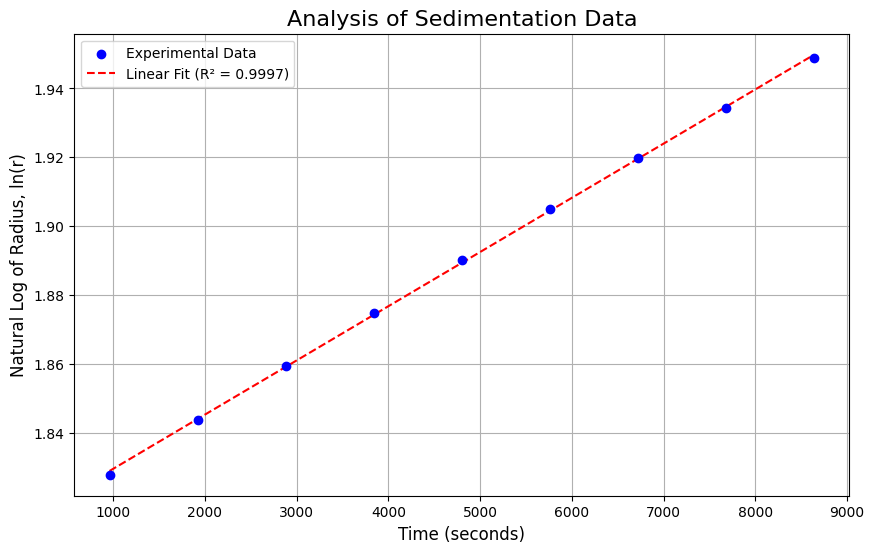

In [5]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

def calculate_sedimentation_coefficient():
    # Time in minutes
    t_min = np.array([16, 32, 48, 64, 80, 96, 112, 128, 144])
    # Distance from rotor center in cm
    r_cm = np.array([6.22, 6.32, 6.42, 6.52, 6.62, 6.72, 6.82, 6.92, 7.02])
    
    # Rotational speed in revolutions per minute
    rpm = 12590

    # Convert time from minutes to seconds
    t_s = t_min * 60
    # Convert rotational speed from rpm to angular velocity (rad/s)
    omega = rpm * 2 * np.pi / 60
    # Calculate the natural logarithm of the radius
    ln_r = np.log(r_cm)

    # --- 3. Linear Regression ---
    # Perform a linear regression of ln(r) vs. time (s) to find the slope
    slope, intercept, r_value, p_value, std_err = linregress(t_s, ln_r)

    # --- 4. Calculate Sedimentation Coefficient ---
    # Calculate s using the formula: s = slope / ω^2
    s_seconds = slope / (omega**2)
    # Convert the sedimentation coefficient to Svedberg units (1 S = 10^-13 s)
    s_svedbergs = s_seconds * 1e13

    # --- 5. Output Results ---
    print("--- Analysis Results ---")
    print(f"Angular Velocity (ω): {omega:.2f} rad/s")
    print(f"Slope of ln(r) vs. time plot: {slope:.4e}")
    print(f"R-squared value of the linear fit: {r_value**2:.4f}\n")
    print(f"Calculated Sedimentation Coefficient: {s_seconds:.4e} s")
    print(f"Sedimentation Coefficient in Svedbergs: {s_svedbergs:.2f} S")
    print("------------------------")

    # --- 6. Generate Plot ---
    plt.figure(figsize=(10, 6))
    plt.scatter(t_s, ln_r, label='Experimental Data', color='blue', zorder=5)
    # Create the line of best fit for plotting
    fit_line = slope * t_s + intercept
    plt.plot(t_s, fit_line, color='red', linestyle='--', label=f'Linear Fit (R² = {r_value**2:.4f})')
    plt.title('Analysis of Sedimentation Data', fontsize=16)
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Natural Log of Radius, ln(r)', fontsize=12)
    plt.legend()
    plt.grid(True)
    
    # Save the plot to a file
    plot_filename = 'sedimentation_analysis_plot.png'
    plt.savefig(plot_filename)
    print(f"\nPlot saved as '{plot_filename}'")


if __name__ == '__main__':
    calculate_sedimentation_coefficient()

## **5. Lipid MIcelles Suspended in Water** ##

Find the **radius** and **D_AB** for dry particles. 

Find **extend of hydration** when D_AB is known to be 6.547x10^-7 cm^2/s

## **6. Colloidal Gold Particles in Aqueous Suspension** ##

Find the **radius** of the particles

The plot has been saved as 'sedimentation_plot.png'
The calculated radius of the gold particles is: 14.42 nm
The calculated radius of the gold particles is: 14.42 nm


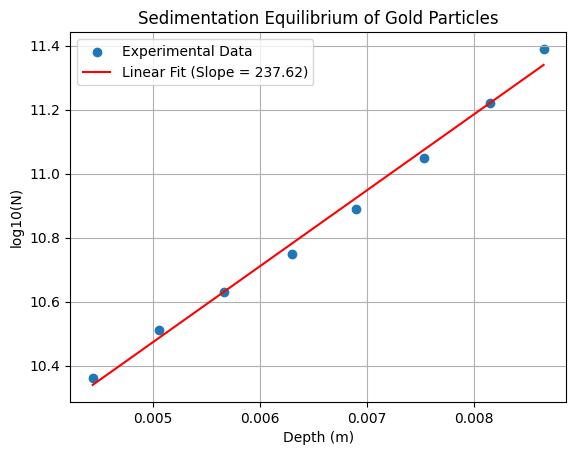

In [ ]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# --- 1. Input Data ---
# The experimental data provided in the problem.
depth_mm = np.array([4.44, 5.06, 5.67, 6.3, 6.9, 7.53, 8.15, 8.65])
log10N = np.array([10.36, 10.51, 10.63, 10.75, 10.89, 11.05, 11.22, 11.39])

# --- 2. Constants in SI Units ---
# Physical constants needed for the calculation.
T = 298  # Temperature in Kelvin (K)
g = 9.8  # Acceleration due to gravity in m/s^2
k = 1.380649e-23  # Boltzmann constant in J/K
rho_gold = 19.3e3  # Density of gold in kg/m^3
rho_water = 1.0e3  # Density of water in kg/m^3

# --- 3. Data Preparation ---
# Convert depth from millimeters to meters to match SI units.
depth_m = depth_mm * 1e-3

# --- 4. Linear Regression ---
# Perform a linear fit on log10N vs. depth in meters.
# The slope is the crucial value we need from the data.
slope, intercept, r_value, p_value, std_err = linregress(depth_m, log10N)

# --- 5. NEW: Plotting the Data and the Fit ---
# Create a scatter plot of the original data points
plt.scatter(depth_m, log10N, label='Experimental Data')

# Create the line of best fit using the slope and intercept from the regression
fit_line = slope * depth_m + intercept
plt.plot(depth_m, fit_line, color='red', label=f'Linear Fit (Slope = {slope:.2f})')

# Add labels and a title for clarity
plt.xlabel("Depth (m)")
plt.ylabel("log10(N)")
plt.title("Sedimentation Equilibrium of Gold Particles")
plt.legend()
plt.grid(True)

# Save the plot to a file
plt.savefig("sedimentation_plot.png")

# --- 6. Calculations ---
# a) Calculate the effective mass from the slope of the line.
m_eff = (slope * 2.303 * k * T) / g

# b) Calculate the actual mass, accounting for buoyancy.
m = m_eff / (1 - (rho_water / rho_gold))

# c) Calculate the volume of a single particle from its mass and density.
V = m / rho_gold

# d) Calculate the radius from the volume, assuming a spherical particle.
r = ((3 * V) / (4 * np.pi))**(1/3)

# e) Convert the radius from meters to nanometers for a more common unit.
r_nm = r * 1e9

# --- 7. Final Result ---
print(f"The plot has been saved as 'sedimentation_plot.png'")
print(f"The calculated radius of the gold particles is: {r_nm:.2f} nm")